In [1]:
import os
import time
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.notebook import tqdm 

from torch.utils.tensorboard import SummaryWriter

import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

from models.oneD_unet_cond import Unet
from ddpm.OneD_ddpm import DDPM
from evaluation.evaluation_metrics import plot_kde_samples, calculate_stat_metrics, plot_metric, calc_acf, plot_acfs, make_gif_from_images

In [2]:
## Data
seq_len = 336
batch_size = 128

#NN
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = "cpu"
cond_model = "mlp"
lr = 1e-4
betas = (0.9, 0.99)
epochs = 5000
save_rate = 50

## DDPM
timesteps = 1000

## Logging
experiment = f"rq1_{seq_len}"
#experiment = "dev"
experiment_name = f"unet_cond_cos_{epochs//1000}kepochs_{seq_len}seq"
logging_dir = f"logging/{experiment}/{experiment_name}/"

In [3]:
if not os.path.isdir(logging_dir):
    os.makedirs(logging_dir)
    os.makedirs(os.path.join(logging_dir, "viz/"))
    os.makedirs(os.path.join(logging_dir, "metrics/"))
    os.makedirs(os.path.join(logging_dir, "kde/"))
    os.makedirs(os.path.join(logging_dir, "tensorboard/"))
    os.makedirs(os.path.join(logging_dir, "weights/"))
    os.makedirs(os.path.join(logging_dir, "time/"))

# Utils

In [4]:
PREPROCESSED_DIR = "./preprocessing/data/customer_led_network_revolution/preprocessed/"

In [5]:
def time_fe(df, timestamps, seq_len):
    num_customer = df.shape[0]
    conditioning_data = np.zeros((num_customer, 4, seq_len)) #4 is the number of features you want to extract

    for i in range(num_customer):
        customer_start_date = timestamps[i]
        for j in range(seq_len):
            current_date = customer_start_date + pd.Timedelta(days=j)
            
            day = current_date.day
            hour = current_date.hour
            minute = current_date.minute
            is_weekend = int(day in([5, 6]))
            
            day_sin = np.sin(2 * np.pi * day / 7)
            hour_sin = np.sin(2 * np.pi * hour / 24)
            minute_sin = np.sin(2 * np.pi * minute / 60)
        
            conditioning_data[i, 0, j] = day_sin
            conditioning_data[i, 1, j] = hour_sin
            conditioning_data[i, 2, j] = minute_sin
            conditioning_data[i, 3, j] = is_weekend

    return conditioning_data

# Load Data

In [6]:
train = pd.read_csv(os.path.join(PREPROCESSED_DIR, "train.csv"), index_col="Location ID")
val = pd.read_csv(os.path.join(PREPROCESSED_DIR, "val.csv"), index_col="Location ID")
test = pd.read_csv(os.path.join(PREPROCESSED_DIR, "test.csv"), index_col="Location ID")

In [7]:
train_seq = train.iloc[:, :seq_len]
train_time = pd.to_datetime(train.columns, format='%d/%m/%Y %H:%M:%S')
train_con = time_fe(train_seq, train_time, seq_len)
train_seq = np.asarray(train_seq).reshape(train_seq.shape[0], 1, train_seq.shape[1])
train_seq.shape, train_con.shape

((3037, 1, 336), (3037, 4, 336))

In [8]:
val_seq = val.iloc[:, :seq_len]
val_time = pd.to_datetime(val.columns, format='%d/%m/%Y %H:%M:%S')
val_con = time_fe(val_seq, val_time, seq_len)
val_seq = np.asarray(val_seq).reshape(val_seq.shape[0], 1, val_seq.shape[1])
val_seq.shape, val_con.shape

((537, 1, 336), (537, 4, 336))

In [9]:
test_seq = test.iloc[:, :seq_len]
test_time = pd.to_datetime(test.columns, format='%d/%m/%Y %H:%M:%S')
test_con = time_fe(test_seq, test_time, seq_len)
test_seq = np.asarray(test_seq).reshape(test_seq.shape[0], 1, test_seq.shape[1])
test_seq.shape, test_con.shape

((894, 1, 336), (894, 4, 336))

In [10]:
train_dataset = TensorDataset(torch.from_numpy(train_seq), torch.from_numpy(train_con))
train_loader = DataLoader(train_dataset, batch_size, shuffle=False)

val_dataset = TensorDataset(torch.from_numpy(val_seq), torch.from_numpy(val_con))
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

test_dataset = TensorDataset(torch.from_numpy(test_seq), torch.from_numpy(test_con))
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

In [11]:
real_data_val, real_cond_data_val = next(iter(val_loader))

# Load model

In [12]:
model = Unet(
    in_channels=train_seq.shape[1],
    out_channels=train_seq.shape[1],
    time_embedding_dim=32,
    base_channels=32,
    channel_mults=(1, 2, 4),
    cond_in_channels=train_con.shape[1],
    cond_sequence_length=seq_len, # Pass sequence length for MLP conditioner
    cond_embedding_dim=32
)

ddpm = DDPM(
        model=model,
        timesteps=timesteps,
        device=device
    )

optim = Adam(model.parameters(), lr=lr)
writer = SummaryWriter(os.path.join(logging_dir, "tensorboard/"))

In [13]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    
    for i, (data, cond_data) in enumerate(train_loader):
        data = data.to(device)
        data = data.float()
        cond_data = cond_data.float()
        cond_data = cond_data.to(device)
        
        optim.zero_grad()
        
        t = torch.randint(0, ddpm.timesteps, (data.shape[0],), device=device)
        
        loss = ddpm.p_losses(data, t, c=cond_data)
        loss.backward()
        
        optim.step()
        running_loss += loss.item()
        
        if i % 100 == 0:
            last_loss = running_loss / 1000 # loss per batch
            tb_x = epoch_index * len(train_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
    return last_loss

In [14]:
start_time = time.time()

epoch_number = 0
best_val_loss = 1_000_000.
save_dir =  os.path.join(logging_dir, "weights/")

for epoch in tqdm(range(1, epochs+1)):
    print('epoch {}:'.format(epoch_number + 1))
    
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)
    
    running_val_loss = 0.0
    
    model.eval()
    with torch.no_grad():
        for i, (val_data, val_cond) in enumerate(val_loader):
            val_data = val_data.to(device)
            val_data = val_data.float()
        
            val_cond = val_cond.float()
            val_cond = val_cond.to(device)
            
            t = torch.randint(0, ddpm.timesteps, (val_data.shape[0],), device=device)
            
            val_loss = ddpm.p_losses(val_data, t, c=val_cond)
            
            running_val_loss += val_loss
    
    avg_val_loss = running_val_loss / (i + 1)
    print('Loss train {} val {}'.format(avg_loss, avg_val_loss))
    
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_val_loss },
                    epoch_number + 1)
    
    writer.flush()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch_number
        best_ddpm_model = ddpm.model.state_dict()
        best_optim_state_dict = optim.state_dict()
        
    
    if epoch_number % save_rate == 0:
        generated_sample = ddpm.sample(batch_size, seq_len=seq_len, features=val_data.shape[1])
        generated_sample = generated_sample.cpu().numpy()
        
        plot_kde_samples(generated_sample, real_data_val,show=False, fpath=os.path.join(logging_dir, "kde/", f"kde_epoch_{epoch_number}.png"), epoch=epoch_number)
        
        model_name = f"model_epoch_{epoch_number}_val_{avg_val_loss:.4f}.pth"
        torch.save({
            'epoch': epoch_number,
            'diffusion_state_dict': ddpm.model.state_dict(),
            'diffusion_optim_state_dict': optim.state_dict()},
            os.path.join(save_dir, model_name))
    
    epoch_number += 1

end_time = time.time()
elapsed_time = end_time - start_time
formatted_time = str(timedelta(seconds=int(elapsed_time)))

  0%|          | 0/5000 [00:00<?, ?it/s]

epoch 1:
Loss train 0.0012894285917282105 val 0.8029252886772156


Sampling loop: 100%|██████████| 1000/1000 [00:03<00:00, 259.23it/s]


epoch 2:
Loss train 0.0004307827353477478 val 0.25923070311546326
epoch 3:
Loss train 0.00024240219593048095 val 0.16928108036518097
epoch 4:
Loss train 0.00017626182734966278 val 0.14763592183589935
epoch 5:
Loss train 0.00015777046978473664 val 0.1409129649400711
epoch 6:
Loss train 0.00012246762216091157 val 0.12414528429508209
epoch 7:
Loss train 0.00011848050355911254 val 0.13275335729122162
epoch 8:
Loss train 0.00011099892854690551 val 0.13876326382160187
epoch 9:
Loss train 0.00013348224759101868 val 0.13177590072155
epoch 10:
Loss train 0.00013436201214790344 val 0.10928565263748169
epoch 11:
Loss train 0.0001074804961681366 val 0.1264774352312088
epoch 12:
Loss train 0.00010622585564851761 val 0.11406469345092773
epoch 13:
Loss train 0.00011088269203901291 val 0.11743345111608505
epoch 14:
Loss train 0.00011175363510847091 val 0.10039673000574112
epoch 15:
Loss train 0.0001131937950849533 val 0.10916633903980255
epoch 16:
Loss train 0.0001173100471496582 val 0.090296201407909

Sampling loop: 100%|██████████| 1000/1000 [00:03<00:00, 257.12it/s]


...

epoch 4852:
Loss train 6.877846270799637e-05 val 0.1233934685587883
epoch 4853:
Loss train 8.270125091075897e-05 val 0.13619112968444824
epoch 4854:
Loss train 7.550203800201416e-05 val 0.11484521627426147
epoch 4855:
Loss train 6.515876203775405e-05 val 0.1266566514968872
epoch 4856:
Loss train 8.114862442016602e-05 val 0.14224804937839508
epoch 4857:
Loss train 7.121288031339646e-05 val 0.11031142622232437
epoch 4858:
Loss train 5.8414023369550707e-05 val 0.10353484004735947
epoch 4859:
Loss train 6.6221684217453e-05 val 0.10752749443054199
epoch 4860:
Loss train 7.488389313220977e-05 val 0.12223812192678452
epoch 4861:
Loss train 7.559695094823837e-05 val 0.1301240175962448
epoch 4862:
Loss train 7.343554496765137e-05 val 0.10702496021986008
epoch 4863:
Loss train 5.384907498955727e-05 val 0.11806165426969528
epoch 4864:
Loss train 6.55798614025116e-05 val 0.12170858681201935
epoch 4865:
Loss train 6.115097180008888e-05 val 0.11129635572433472
epoch 4866:
Loss train 9.28558856248855

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 99.96it/s]


epoch 4902:
Loss train 7.08501935005188e-05 val 0.11934585869312286
epoch 4903:
Loss train 7.314415276050568e-05 val 0.10812635719776154
epoch 4904:
Loss train 7.201400399208069e-05 val 0.11924272030591965
epoch 4905:
Loss train 0.0001024477705359459 val 0.1113596111536026
epoch 4906:
Loss train 7.670526206493378e-05 val 0.10797833651304245
epoch 4907:
Loss train 8.247701823711396e-05 val 0.10901214182376862
epoch 4908:
Loss train 7.266069203615188e-05 val 0.09695862233638763
epoch 4909:
Loss train 6.818147003650665e-05 val 0.12037023156881332
epoch 4910:
Loss train 7.104336470365525e-05 val 0.11865977197885513
epoch 4911:
Loss train 7.344930619001389e-05 val 0.10061898082494736
epoch 4912:
Loss train 6.888923048973084e-05 val 0.1279129683971405
epoch 4913:
Loss train 8.228211104869843e-05 val 0.10859943926334381
epoch 4914:
Loss train 7.86888301372528e-05 val 0.13515274226665497
epoch 4915:
Loss train 7.118703424930572e-05 val 0.12168226391077042
epoch 4916:
Loss train 8.6556293070316

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 99.96it/s]


epoch 4952:
Loss train 6.94446936249733e-05 val 0.1266053020954132
epoch 4953:
Loss train 8.273681253194809e-05 val 0.12126709520816803
epoch 4954:
Loss train 6.646393239498139e-05 val 0.14214156568050385
epoch 4955:
Loss train 7.80496597290039e-05 val 0.11550916731357574
epoch 4956:
Loss train 6.012202426791191e-05 val 0.13319021463394165
epoch 4957:
Loss train 7.493062317371368e-05 val 0.09984618425369263
epoch 4958:
Loss train 9.02848020195961e-05 val 0.12091922760009766
epoch 4959:
Loss train 8.856097608804702e-05 val 0.12212562561035156
epoch 4960:
Loss train 5.888422578573227e-05 val 0.11513260751962662
epoch 4961:
Loss train 8.219660818576813e-05 val 0.12949195504188538
epoch 4962:
Loss train 9.58712324500084e-05 val 0.13181622326374054
epoch 4963:
Loss train 7.38692432641983e-05 val 0.12990276515483856
epoch 4964:
Loss train 8.891447633504867e-05 val 0.1279008835554123
epoch 4965:
Loss train 7.971271872520447e-05 val 0.13403528928756714
epoch 4966:
Loss train 7.748305052518845e

In [15]:
out_path = os.path.join(logging_dir, "time/", "compute_time.txt")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w") as f:
    f.write(f"Time to train {epochs} epochs with batch size {batch_size} and sequece {seq_len}: {formatted_time}")

In [16]:
model_name = f"best_model.pth"
torch.save({
    'epoch': best_epoch,
    'diffusion_state_dict': best_ddpm_model,
    'diffusion_optim_state_dict': best_optim_state_dict},
    os.path.join(logging_dir, "weights/", model_name))

In [17]:
ddpm.model.load_state_dict(torch.load(os.path.join(logging_dir, "weights/", "best_model.pth"))["diffusion_state_dict"])

C:\Users\Arne\AppData\Local\Temp\ipykernel_4984\1150675024.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ddpm.model.load_state_dict(torch.load(os.path.join(logging_dir

<All keys matched successfully>

In [18]:
paths = []
for kde_plot in os.listdir(os.path.join(logging_dir, "kde/")):
    paths.append(os.path.join(logging_dir, "kde/", kde_plot))

make_gif_from_images(paths, os.path.join(logging_dir, "kde/", "kde_progression.gif"))

# Evaluation

In [19]:
real_data_test, real_cond_data_test = next(iter(test_loader))

In [20]:
with torch.no_grad():
    samples = ddpm.sample(batch_size, seq_len=seq_len, features=val_data.shape[1], c=real_cond_data_test.float().to(device))
    samples = samples.cpu().numpy()

print(f"Samples shape: {samples.shape}")

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 93.04it/s]

Samples shape: (128, 1, 336)


## Basic Statistical Features

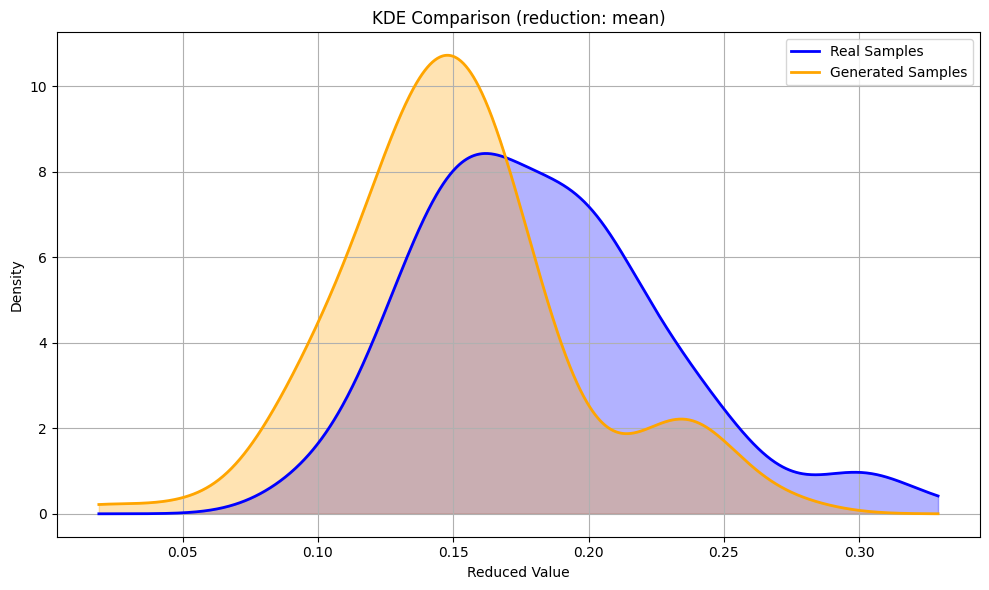

In [21]:
plot_kde_samples(samples, real_data_test, fpath=os.path.join(logging_dir, "kde/", f"kde.png"))

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 92.98it/s]


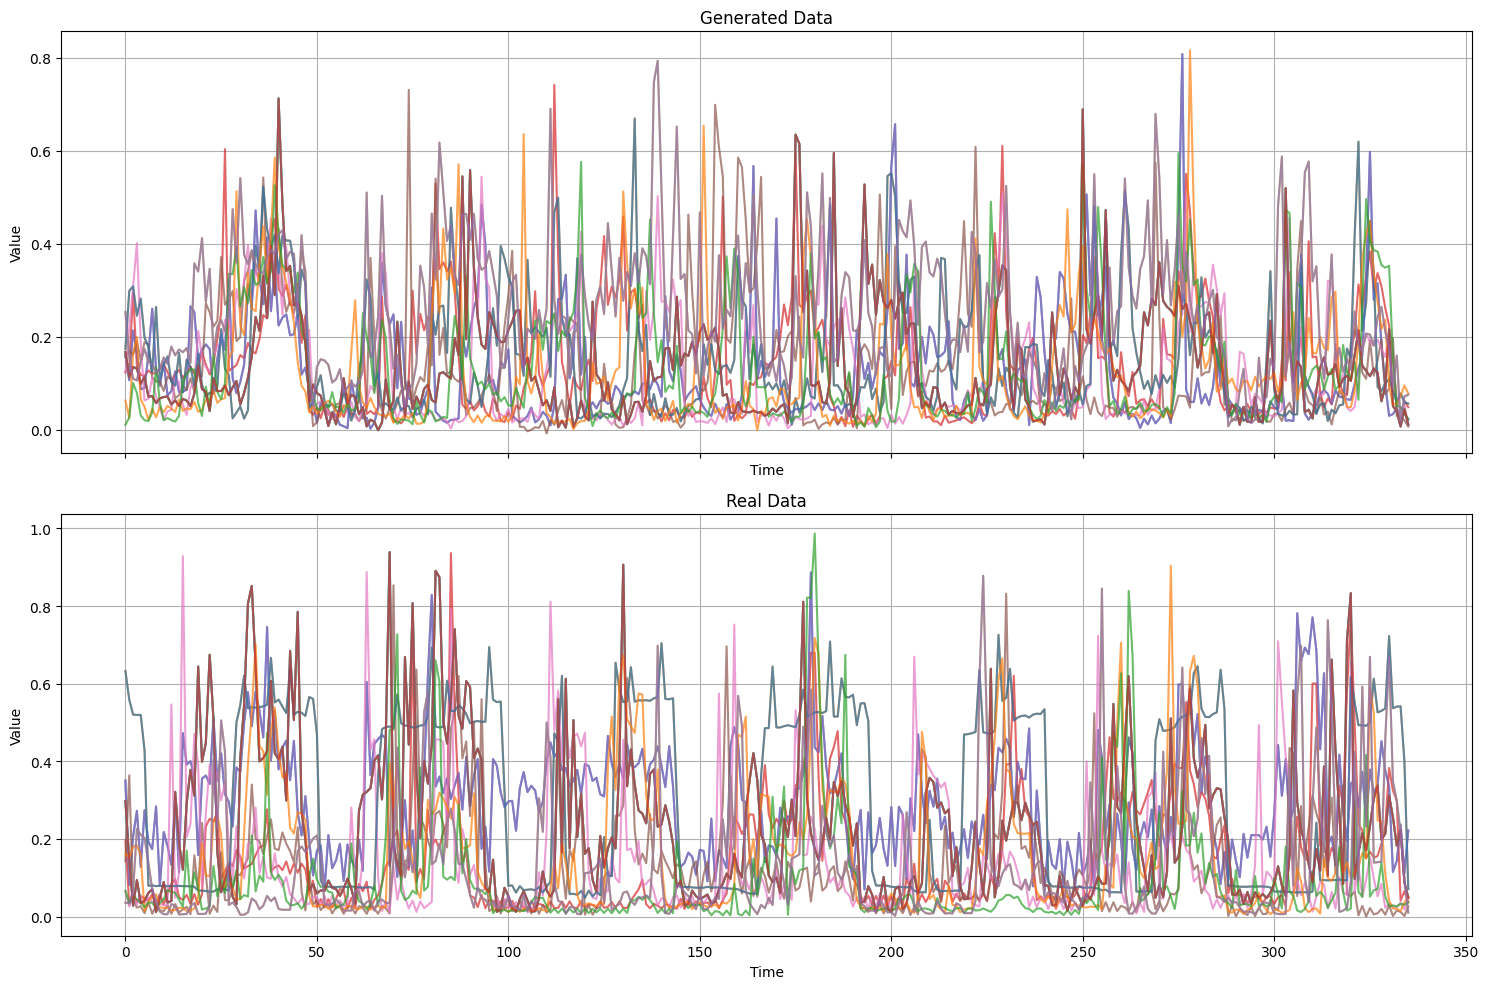

In [22]:
### REDO THIS
batch_idx = np.random.randint(0, 256) 
customer_indices = np.random.randint(0, 15, size=15)
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

with torch.no_grad():
    sample = ddpm.sample(batch_size, seq_len=seq_len, features=val_data.shape[1], c=real_cond_data_test.float().to(device)) 
    sample = sample.cpu().numpy() 

for i in customer_indices:
    axs[0].plot(sample[i, 0, :], alpha=0.7, label=f'Customer {i}')
    axs[1].plot(real_data_test[i, 0, :], alpha=0.7, label=f'Customer {i}')

axs[0].set_title("Generated Data")
axs[1].set_title("Real Data")

for ax in axs:
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(logging_dir, "viz/", "samples.png"))
plt.show()

In [23]:
gen_mean, gen_sd, gen_kurt, gen_skew, gen_min, gen_max = calculate_stat_metrics(samples, batch_size)
real_mean, real_sd, real_kurt, real_skew, real_min, real_max = calculate_stat_metrics(real_data_test, batch_size)

Plot for 'Mean' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/mean.png


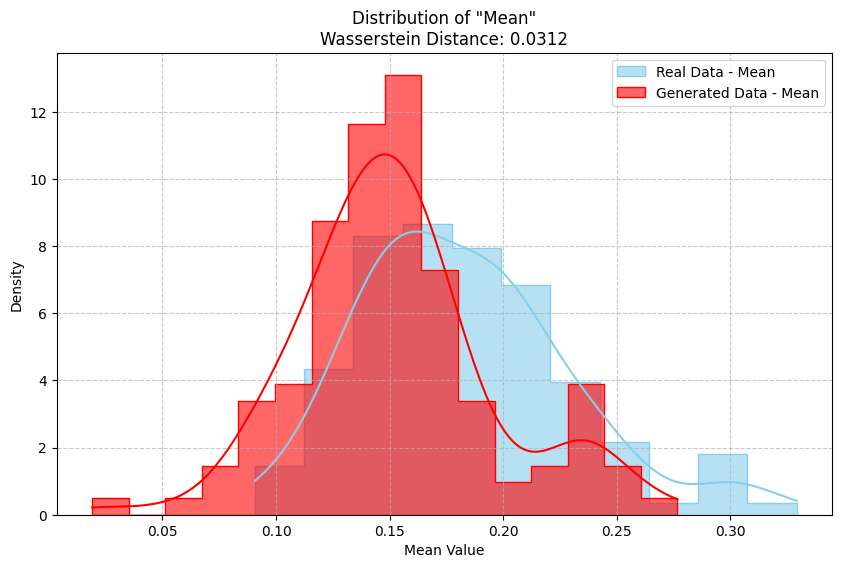

0.031200120359108574

In [24]:
plot_metric(real_mean, gen_mean, "Mean", save_path=os.path.join(logging_dir, "metrics/", f"mean.png"))

Plot for 'Standard Deviation' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/sd.png


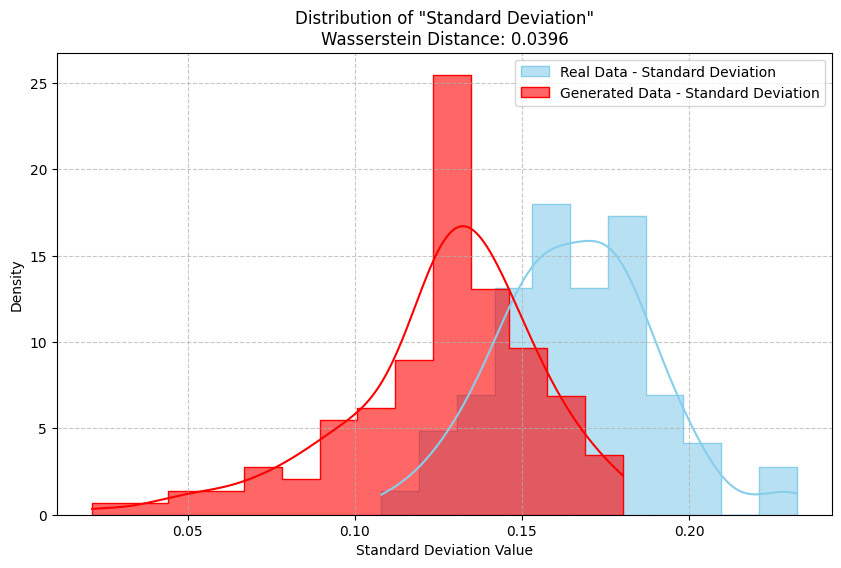

0.03955835789700854

In [25]:
plot_metric(real_sd, gen_sd, "Standard Deviation", save_path=os.path.join(logging_dir, "metrics/", f"sd.png"))

Plot for 'Kurtosis' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/kurt.png


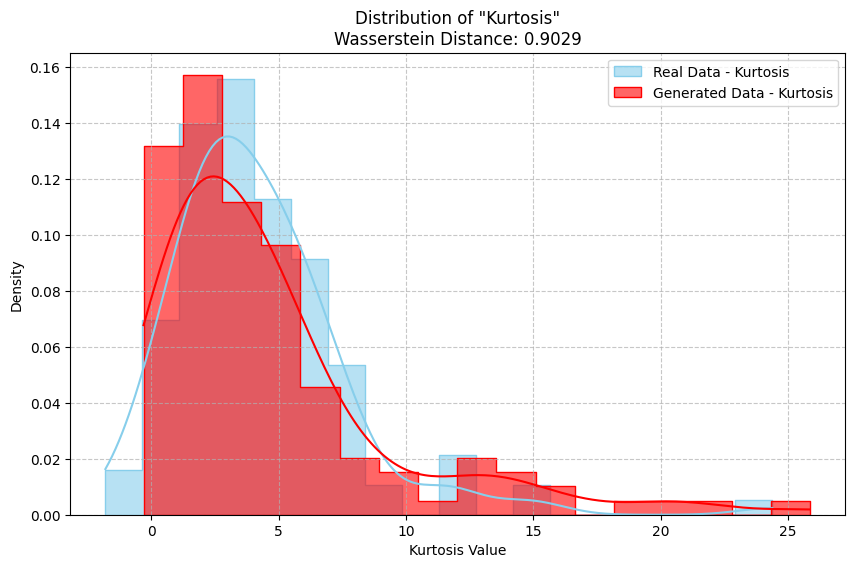

0.9029413619503596

In [26]:
plot_metric(real_kurt, gen_kurt, "Kurtosis", save_path=os.path.join(logging_dir, "metrics/", f"kurt.png"))

Plot for 'Skew' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/skew.png


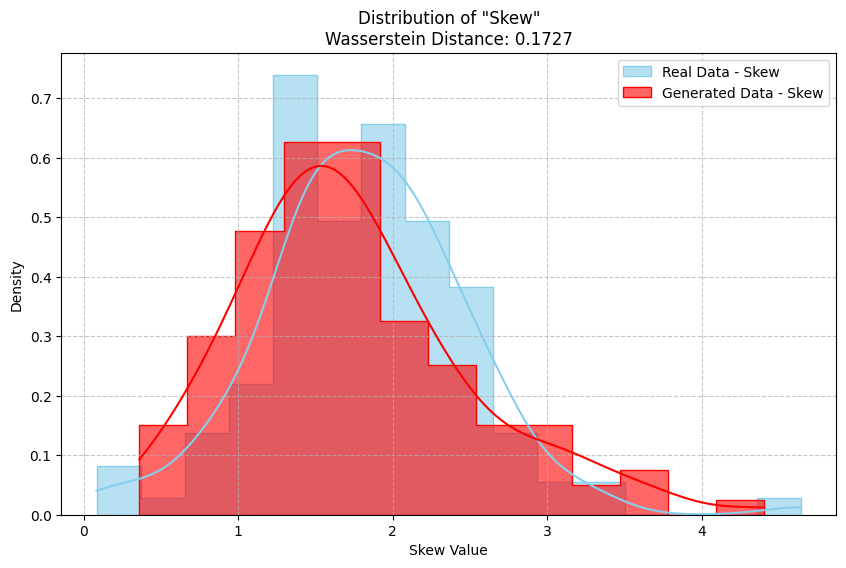

0.1726608978737178

In [27]:
plot_metric(real_skew, gen_skew, "Skew", save_path=os.path.join(logging_dir, "metrics/", f"skew.png"))

Plot for 'Min value' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/min.png


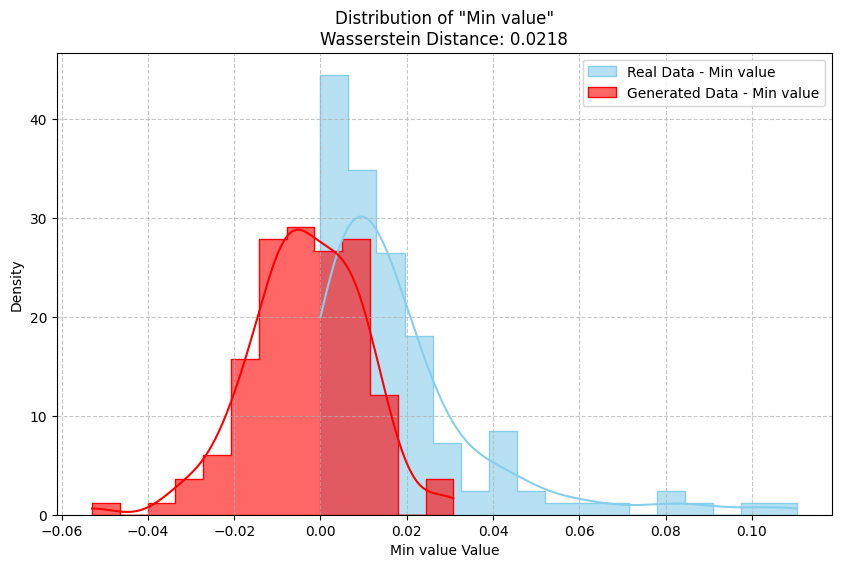

0.021801723907361382

In [28]:
plot_metric(real_min, gen_min, "Min value", save_path=os.path.join(logging_dir, "metrics/", f"min.png"))

Plot for 'Max value' saved to logging/rq1_336/unet_cond_cos_5kepochs_336seq/metrics/max.png


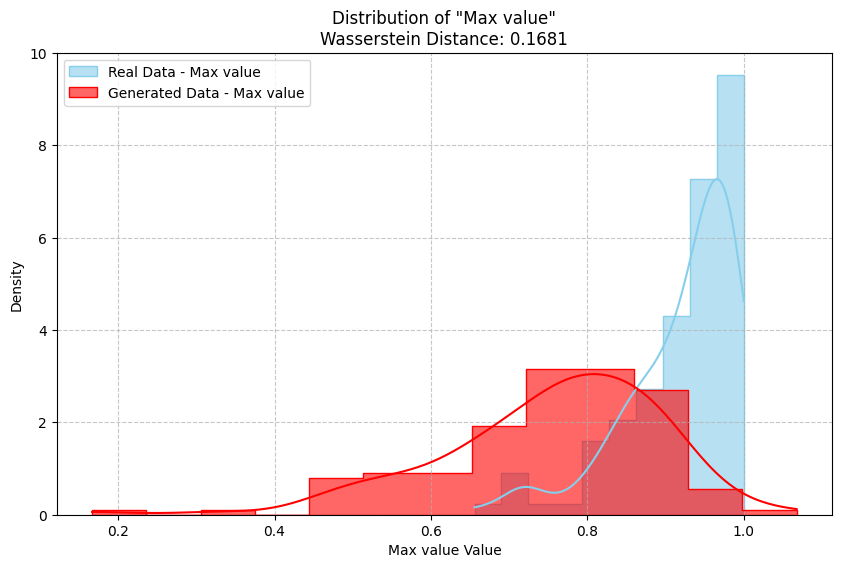

0.16805229213830886

In [29]:
plot_metric(real_max, gen_max, "Max value", save_path=os.path.join(logging_dir, "metrics/", f"max.png"))

## Temporal / Dynamic Features

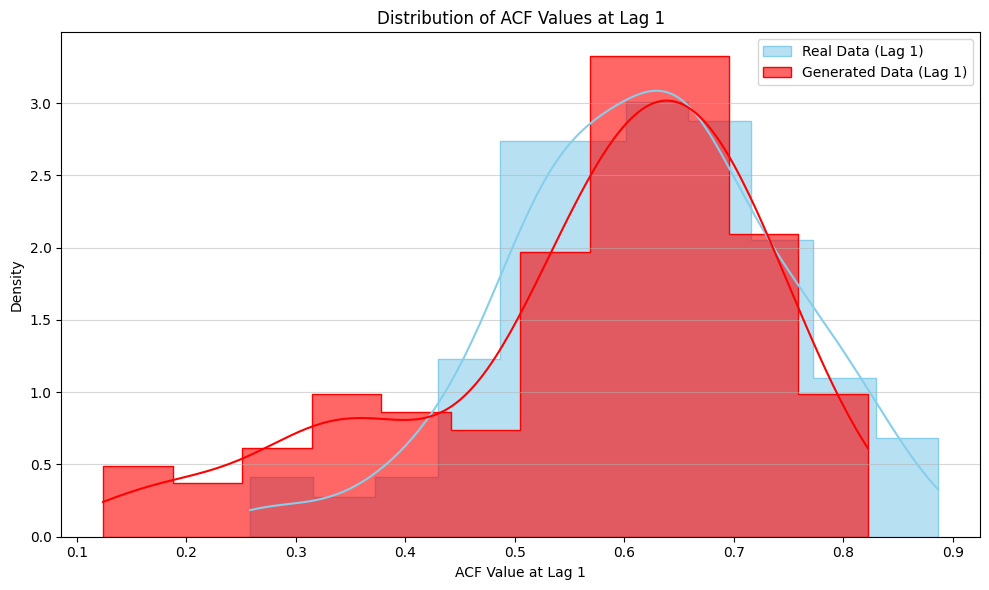

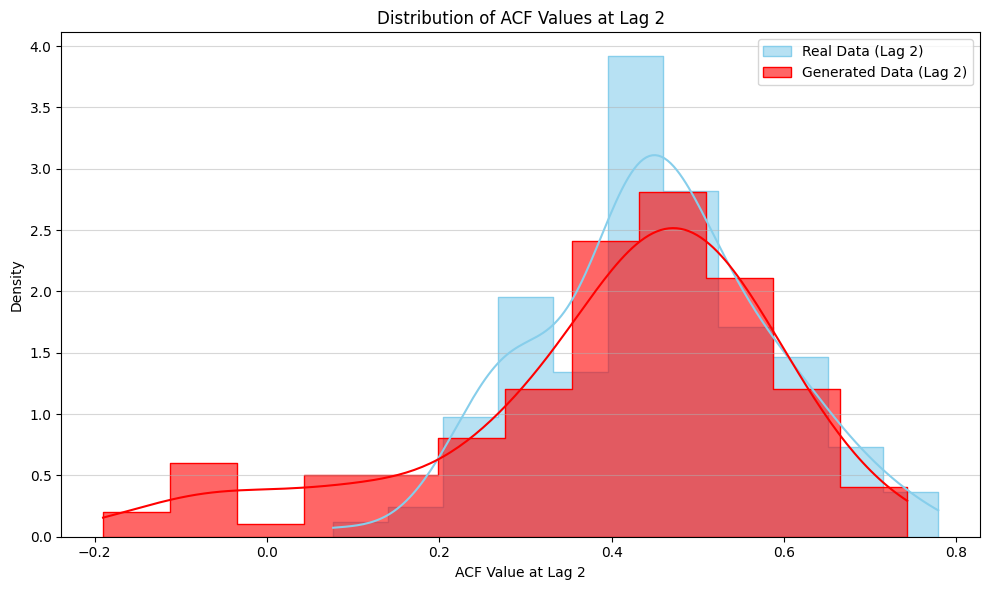

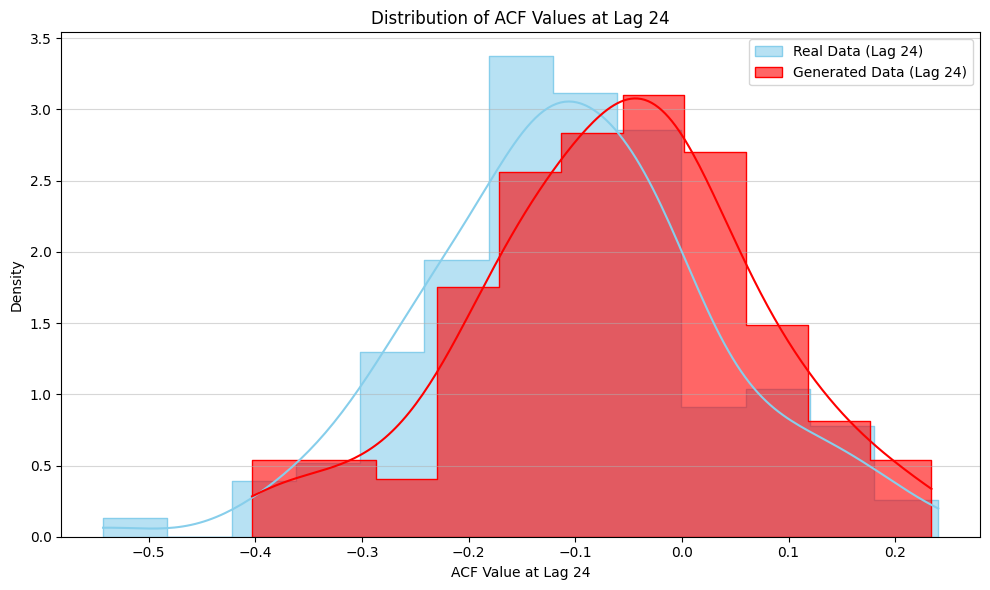

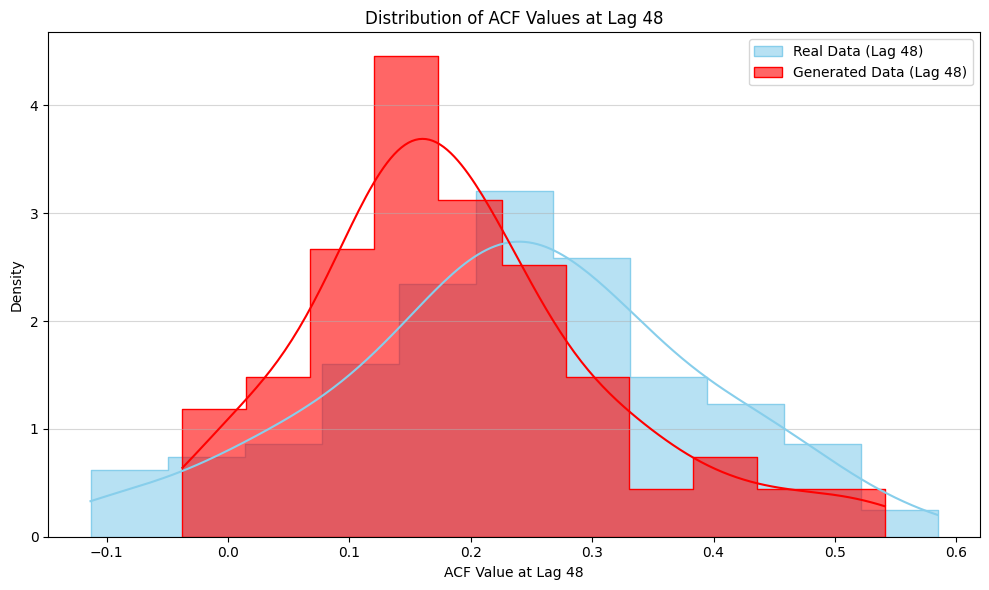

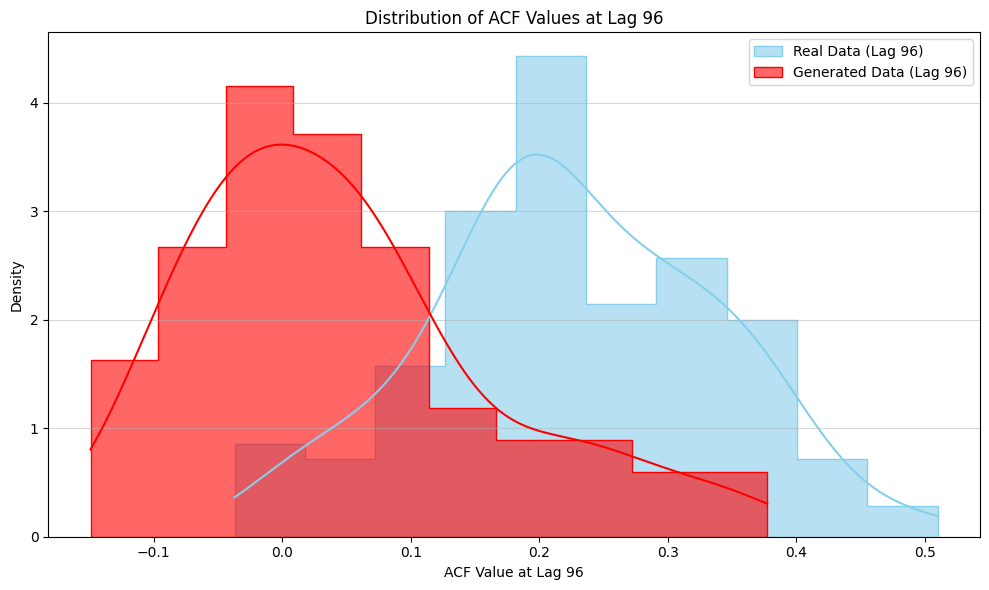

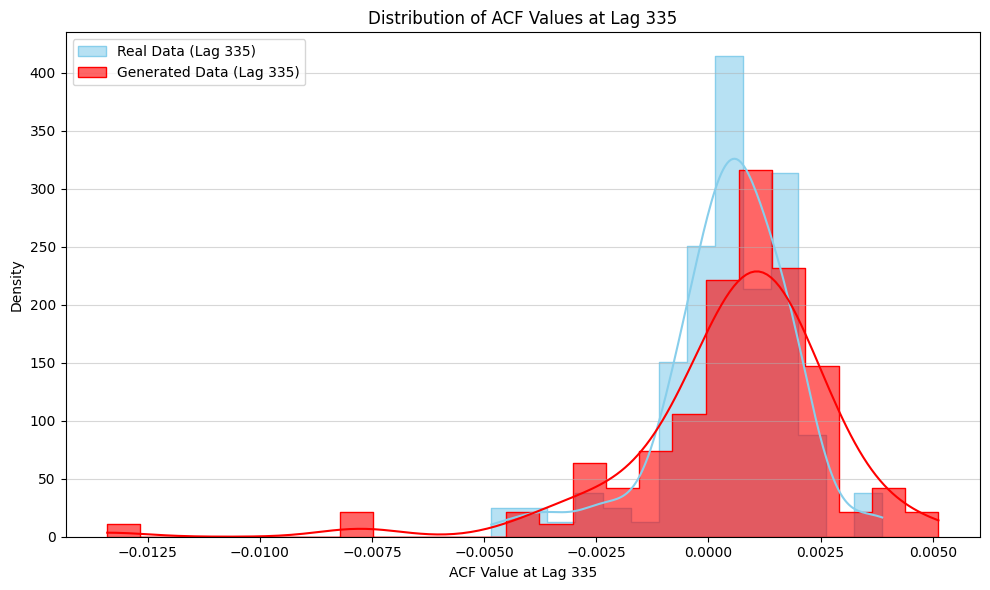

In [30]:
lags = [1, 2, 24, 48, 96, 335]

for lag in lags:
    real_acf = calc_acf(real_data_test, lag)
    gen_acf = calc_acf(samples, lag)
    
    plot_acfs(real_acf, gen_acf, lag, save_path=os.path.join(logging_dir, "metrics/", f"ACF_{lag}.png"))